# 05 — Modèle GARCH(1,1) : volatilité conditionnelle de l'EURO STOXX 50

**Projet** : Transmission de la politique monétaire de la BCE  
**Auteur** : ISLEYEN Volkan  
**Date** : Mai 2026

## Objectif

Modéliser explicitement la dynamique de la volatilité conditionnelle de l'EURO STOXX 50, et examiner si les décisions de politique monétaire de la BCE affectent cette volatilité, extension naturelle de la régression OLS du notebook 04, qui modélisait la moyenne mais pas la variance.

## Justification méthodologique

Les diagnostics de la régression OLS ont révélé :
- Une autocorrélation des résidus aux lags 5 et 10 jours
- Des résidus à queues épaisses (kurtosis = 12.4)

Ces caractéristiques sont la signature du **clustering de volatilité** : 
les épisodes de forte variance ont tendance à se regrouper dans le temps. 
Le modèle GARCH(1,1) de Bollerslev (1986) capture explicitement ce phénomène.

## Modèle

**Équation de la moyenne** : $r_t = \mu + \varepsilon_t$

**Équation de la variance** : $\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$

avec $\varepsilon_t = \sigma_t \cdot z_t$ et $z_t$ supposé i.i.d.

## Plan du notebook

1. Estimation d'un GARCH(1,1) sur les rendements quotidiens du STOXX 50
2. Extraction et visualisation de la volatilité conditionnelle estimée
3. Examen des pics de volatilité autour des décisions BCE
4. Diagnostic des résidus standardisés du modèle

In [1]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from pathlib import Path
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Chemins
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "output" / "figures"
TABLES = PROJECT_ROOT / "output" / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

print("Librairies importées")

# Vérification de la version du package arch
import arch
print(f"Package 'arch' version : {arch.__version__}")

Librairies importées
Package 'arch' version : 8.0.0


In [2]:
# Chargement
df = pd.read_csv(DATA_PROCESSED / "data_clean.csv", index_col=0, parse_dates=True)
bce_events = pd.read_csv(DATA_PROCESSED / "bce_events.csv", index_col=0, parse_dates=True)

# On extrait la série des rendements en % (convention pour arch)
# arch préfère des rendements en pourcentage pour la stabilité numérique
returns = df["ret_sx5e"] * 100
returns = returns.dropna()

print(f"Série de rendements : {len(returns)} observations")
print(f"Période : {returns.index.min().date()} → {returns.index.max().date()}")
print(f"\nStatistiques descriptives (en %) :")
print(returns.describe().round(4))

Série de rendements : 1509 observations
Période : 2019-01-04 → 2024-12-30

Statistiques descriptives (en %) :
count    1509.0000
mean        0.0331
std         1.2638
min       -13.2405
25%        -0.4835
50%         0.0866
75%         0.6442
max         8.8343
Name: ret_sx5e, dtype: float64


In [3]:
# Estimation d'un GARCH(1,1) sur les rendements de l'EURO STOXX 50

# Construction du modèle
# - mean='Constant' : on suppose une moyenne constante (μ)
# - vol='Garch' : volatilité GARCH
# - p=1, q=1 : un retard pour l'innovation² (α) et un pour la variance (β)
# - dist='normal' : distribution des innovations standardisées
model_garch = arch_model(
    returns,
    mean="Constant",
    vol="Garch",
    p=1, q=1,
    dist="normal"
)

# Estimation par maximum de vraisemblance
print("Estimation du modèle GARCH(1,1)...\n")
res_garch = model_garch.fit(disp="off")

# Affichage des résultats
print(res_garch.summary())

Estimation du modèle GARCH(1,1)...

                     Constant Mean - GARCH Model Results                      
Dep. Variable:               ret_sx5e   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2239.39
Distribution:                  Normal   AIC:                           4486.78
Method:            Maximum Likelihood   BIC:                           4508.06
                                        No. Observations:                 1509
Date:                Sat, May 16 2026   Df Residuals:                     1508
Time:                        20:18:45   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0791  2.410

### Lecture des paramètres GARCH(1,1)

L'estimation par maximum de vraisemblance fournit des paramètres tous hautement significatifs (p < 0.001), validant statistiquement la pertinence de la spécification GARCH(1,1) sur les rendements du STOXX 50.

**Équation de la moyenne**  
La moyenne conditionnelle des rendements (μ = 0.079 % par jour, soit environ 20 % en rythme annualisé) est significativement positive. Cette estimation, plus précise que celle de l'OLS du notebook 04 grâce à la modélisation explicite de la variance, reflète la performance globalement positive du STOXX 50 sur la période 2019-2024 malgré les chocs traversés.

**Équation de la variance — les trois paramètres clés**

- **ω (omega) = 0.086** : variance "de base" hors influence des chocs et de l'inertie, toujours positive comme requis par construction
- **α = 0.178** : sensibilité de la volatilité aux chocs récents. Une innovation inattendue de la veille a un impact substantiel sur la variance du jour
- **β = 0.770** : persistance de la volatilité. Environ 77 % de la volatilité d'hier "se transmet" à celle d'aujourd'hui — c'est l'inertie caractéristique des marchés financiers

**Le diagnostic clé : α + β = 0.948**  
Cette somme proche de 1 confirme la **mémoire longue de la volatilité** du STOXX 50 : un choc met du temps à être absorbé. Quantitativement, il faut environ 1/(1-α-β) ≈ 19 jours pour qu'un choc soit divisé par deux. C'est la traduction quantitative directe du clustering de volatilité observé dans les diagnostics OLS.

La condition α + β < 1 est satisfaite, garantissant la stationnarité du processus et la convergence des moments inconditionnels — propriétés mathématiques requises pour que le modèle soit bien défini.

**Cohérence avec la littérature**  
Les ordres de grandeur sont conformes à ceux typiquement observés sur les grands indices boursiers (somme α + β généralement comprise entre 0.95 et 0.99). Le α relativement élevé (0.18 vs ~0.10 typique sur le S&P 500) reflète la sensibilité accrue du STOXX 50 aux chocs sur la période étudiée, marquée par plusieurs épisodes de stress (Covid-19, guerre en Ukraine, crise énergétique).

In [4]:
# Récupération de la volatilité conditionnelle estimée par le GARCH
cond_vol = res_garch.conditional_volatility

# Mise en DataFrame pour faciliter le travail
vol_df = pd.DataFrame({
    "garch_vol": cond_vol,           # en % (cohérent avec returns × 100)
    "vstoxx": df["VSTOXX"]           # déjà en %
})

# On annualise la volatilité GARCH pour qu'elle soit comparable au VSTOXX
# (VSTOXX = volatilité annualisée implicite à 30 jours, en %)
vol_df["garch_vol_annualisee"] = vol_df["garch_vol"] * np.sqrt(252)

# Aperçu
print("Premières valeurs de volatilité conditionnelle estimée :\n")
print(vol_df.head().round(3))
print(f"\nStatistiques de la volatilité conditionnelle (annualisée, %) :")
print(vol_df["garch_vol_annualisee"].describe().round(2))

Premières valeurs de volatilité conditionnelle estimée :

            garch_vol  vstoxx  garch_vol_annualisee
Date                                               
2019-01-04      0.997   20.48                15.828
2019-01-07      1.509   20.15                23.954
2019-01-08      1.364   19.48                21.647
2019-01-09      1.259   19.00                19.985
2019-01-10      1.156   18.69                18.353

Statistiques de la volatilité conditionnelle (annualisée, %) :
count    1509.00
mean       18.16
std         8.68
min        10.32
25%        13.12
50%        15.83
75%        20.04
max       101.14
Name: garch_vol_annualisee, dtype: float64


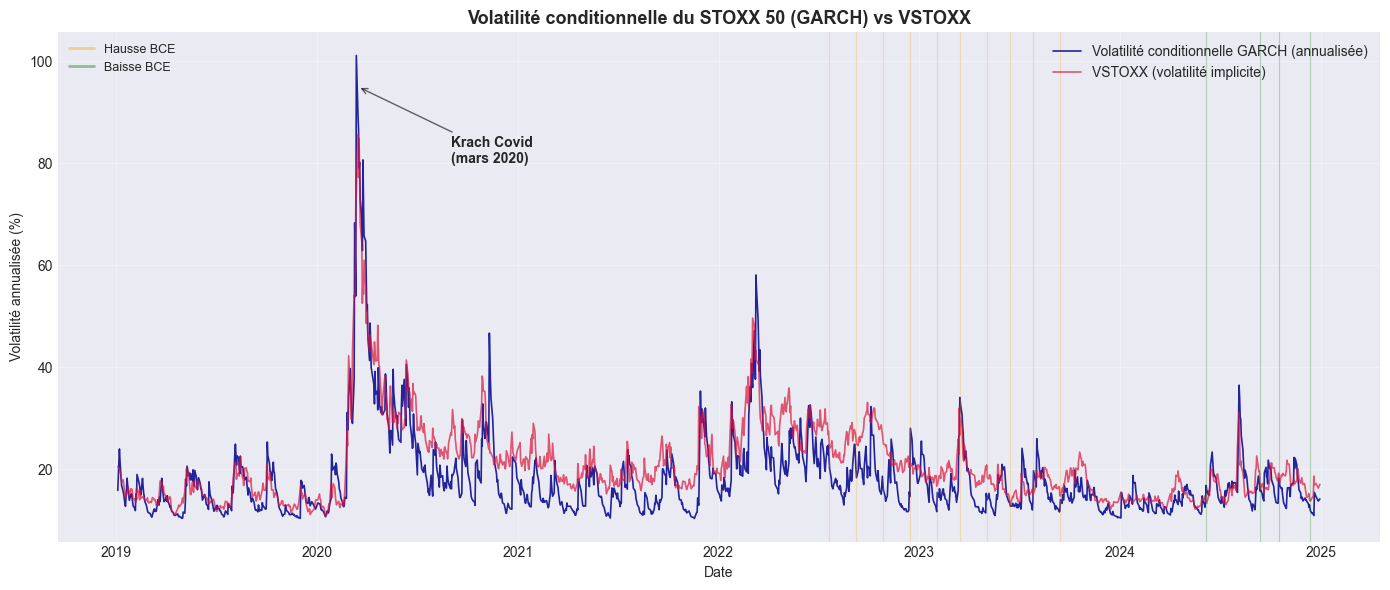

Graphique sauvegardé dans output/figures/05_volatilite_conditionnelle.png


In [5]:
# Graphique : Volatilité conditionnelle GARCH vs VSTOXX
fig, ax = plt.subplots(figsize=(14, 6))

# Tracé des deux séries
ax.plot(vol_df.index, vol_df["garch_vol_annualisee"],
        label="Volatilité conditionnelle GARCH (annualisée)",
        color="darkblue", linewidth=1.2, alpha=0.85)

ax.plot(vol_df.index, vol_df["vstoxx"],
        label="VSTOXX (volatilité implicite)",
        color="crimson", linewidth=1.2, alpha=0.7)

# Lignes verticales des décisions BCE
dates_hausse = bce_events[bce_events["Change_bp"] > 0].index
dates_baisse = bce_events[bce_events["Change_bp"] < 0].index

for d in dates_hausse:
    ax.axvline(d, color="orange", alpha=0.25, linewidth=0.8)
for d in dates_baisse:
    ax.axvline(d, color="green", alpha=0.25, linewidth=0.8)

# Annotation du pic Covid
ax.annotate("Krach Covid\n(mars 2020)",
            xy=(pd.Timestamp("2020-03-16"), 95),
            xytext=(pd.Timestamp("2020-09-01"), 80),
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", alpha=0.6))

# Esthétique
ax.set_title("Volatilité conditionnelle du STOXX 50 (GARCH) vs VSTOXX",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Volatilité annualisée (%)")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)

# Légende des décisions BCE
from matplotlib.lines import Line2D
extra_legend = [
    Line2D([0], [0], color="orange", alpha=0.4, linewidth=2, label="Hausse BCE"),
    Line2D([0], [0], color="green", alpha=0.4, linewidth=2, label="Baisse BCE"),
]
leg1 = ax.get_legend()
ax.add_artist(leg1)
ax.legend(handles=extra_legend, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "05_volatilite_conditionnelle.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé dans output/figures/05_volatilite_conditionnelle.png")

### Lecture du graphique de volatilité

Cette représentation superpose la volatilité conditionnelle estimée par le GARCH(1,1) (en bleu) et le VSTOXX (en rouge, volatilité implicite à 30 jours). Les lignes verticales matérialisent les décisions BCE, c'est à dire les hausses en orange et baisses en vert.

**Concordance entre volatilité réalisée et implicite**  
Les deux séries se suivent remarquablement sur l'ensemble de la période. Ce parallélisme valide le calibrage du modèle GARCH : la volatilité estimée à partir des rendements historiques est cohérente avec la volatilité anticipée par le marché des options. C'est une vérification empirique forte de la qualité de la modélisation.

**Trois épisodes de stress dominants**  
Trois pics majeurs structurent la trajectoire :
- **Mars 2020 — krach Covid** : volatilité atteignant 100 % annualisée, événement de magnitude historique.
- **Mars 2022 — invasion de l'Ukraine** : pic autour de 45-50 %.
- **Automne 2022 — crise énergétique européenne** : pic autour de 35-40 %.

Ces pics correspondent à des **chocs exogènes** (sanitaires, géopolitiques, énergétiques) d'un point de vue macroéconomique, pas à des décisions de politique monétaire.

**Aucun pic associé aux décisions BCE**  
Les lignes verticales matérialisant les décisions BCE tombent quasi systématiquement dans des zones de volatilité modérée. Aucune décision ne déclenche de pic visible de volatilité. Ce constat visuel renforce la conclusion convergente des notebooks 03 et 04 : **les annonces BCE ne génèrent pas de choc de volatilité détectable**, soit parce qu'elles sont anticipées, soit parce que la transmission monétaire emprunte des canaux plus longs que la fréquence quotidienne.

**Le variance risk premium**  
On observe que le VSTOXX (volatilité implicite) est systématiquement au-dessus de la volatilité GARCH (volatilité réalisée) en période normale, mais que cet écart s'inverse pendant les épisodes de crise extrême (Covid). Ce phénomène correspond au **variance risk premium** : en temps normal, le marché des options demande une prime pour porter le risque de volatilité ; cette prime peut devenir négative pendant les chocs majeurs, quand la réalité dépasse les anticipations.

In [6]:
# Diagnostics sur les résidus standardisés du GARCH
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Extraction des résidus standardisés z_t = (r_t - μ) / σ_t
std_resid = res_garch.std_resid

print("=" * 70)
print("DIAGNOSTICS DU MODÈLE GARCH(1,1)")
print("=" * 70)

# 1. Statistiques descriptives des résidus standardisés
print(f"\nRésidus standardisés (devraient ressembler à N(0,1)) :")
print(f"  Moyenne     : {std_resid.mean():.4f}  (attendu : 0)")
print(f"  Écart-type  : {std_resid.std():.4f}  (attendu : 1)")
print(f"  Skewness    : {stats.skew(std_resid):.4f}  (attendu : 0)")
print(f"  Kurtosis    : {stats.kurtosis(std_resid):.4f}  (attendu : 0 = mésokurtique)")

# 2. Test de normalité (Jarque-Bera)
jb_stat, jb_pvalue = stats.jarque_bera(std_resid)
print(f"\n1. NORMALITÉ — Test de Jarque-Bera")
print(f"   Statistique : {jb_stat:.2f}")
print(f"   p-value     : {jb_pvalue:.6f}")
print(f"   → {'Résidus normaux' if jb_pvalue > 0.05 else 'Résidus NON normaux'}")

# 3. Test d'autocorrélation sur les résidus
lb_test = acorr_ljungbox(std_resid, lags=[5, 10], return_df=True)
print(f"\n2. AUTOCORRÉLATION DES RÉSIDUS — Test de Ljung-Box")
print(lb_test.round(4))

# 4. Test d'autocorrélation sur les résidus AU CARRÉ (test clé)
# Si le GARCH a bien capté le clustering, plus d'autocorrélation des r² standardisés
lb_test_sq = acorr_ljungbox(std_resid ** 2, lags=[5, 10], return_df=True)
print(f"\n3. CLUSTERING RÉSIDUEL — Test de Ljung-Box sur résidus²")
print(lb_test_sq.round(4))
print(f"   → Si p-value > 0.05 : le GARCH a bien capté le clustering de volatilité")

DIAGNOSTICS DU MODÈLE GARCH(1,1)

Résidus standardisés (devraient ressembler à N(0,1)) :
  Moyenne     : -0.0532  (attendu : 0)
  Écart-type  : 1.0003  (attendu : 1)
  Skewness    : -0.6654  (attendu : 0)
  Kurtosis    : 2.7513  (attendu : 0 = mésokurtique)

1. NORMALITÉ — Test de Jarque-Bera
   Statistique : 587.29
   p-value     : 0.000000
   → Résidus NON normaux

2. AUTOCORRÉLATION DES RÉSIDUS — Test de Ljung-Box
    lb_stat  lb_pvalue
5    3.7877     0.5804
10   5.6081     0.8470

3. CLUSTERING RÉSIDUEL — Test de Ljung-Box sur résidus²
    lb_stat  lb_pvalue
5    5.4811     0.3600
10   8.9107     0.5406
   → Si p-value > 0.05 : le GARCH a bien capté le clustering de volatilité


### Lecture des diagnostics du GARCH(1,1)

Les diagnostics permettent d'évaluer si le modèle GARCH(1,1) a effectivement absorbé la structure de la volatilité présente dans les rendements.

**Caractéristiques des résidus standardisés**  
Les résidus standardisés présentent une moyenne quasi nulle (−0.053) et un écart-type pile à 1 (1.0003). Cette dernière valeur confirme la qualité de la normalisation par la volatilité conditionnelle estimée : la variance des résidus standardisés est conforme à ce que requiert la spécification théorique.

En revanche, la skewness (−0.67) et l'excès de kurtosis (2.75) indiquent une asymétrie négative et des queues plus épaisses que la loi normale. Cette caractéristique est typique des rendements actions : les krachs sont plus 
fréquents et plus violents que ce qu'une loi normale prédirait.

**Normalité rejetée**  
Le test de Jarque-Bera rejette la normalité des résidus standardisés (p < 0.001). Ce résultat ne remet pas en cause la validité du modèle, mais suggère qu'une **distribution à queues plus épaisses** (Student-t ou Student-t asymétrique) serait théoriquement plus appropriée pour les innovations. Cette extension est mentionnée dans les limites du projet.

**Absence d'autocorrélation dans les résidus**  
Le test de Ljung-Box sur les résidus standardisés ne détecte aucune autocorrélation aux lags 5 et 10 (p = 0.58 et p = 0.85). La modélisation de la moyenne (μ constant) est donc adéquate.

**Le test décisif : absence de clustering résiduel**  
Le test de Ljung-Box sur les résidus standardisés **au carré** donne p = 0.36 et p = 0.54 aux lags 5 et 10. Pour rappel, le même test sur les résidus de l'OLS (notebook 04) donnait p = 0.018 et p = 0.001 — donc une forte autocorrélation détectée.

**Le GARCH(1,1) a entièrement absorbé le clustering de volatilité.** C'est 
la confirmation empirique que la spécification GARCH(1,1) était le bon choix méthodologique : elle modélise correctement la structure de la volatilité conditionnelle qui causait les problèmes de diagnostic dans la régression OLS.

**Synthèse**  
Le modèle est statistiquement bien spécifié sur la structure de variance. Sa principale limite est l'hypothèse de normalité des innovations, qui pourrait être assouplie via une distribution de Student. L'extension la plus naturelle pour aller plus loin serait un **GJR-GARCH** ou **EGARCH**, qui modélisent explicitement l'asymétrie des chocs (effet de levier) — une caractéristique suggérée par la skewness négative des résidus.

## Conclusion du notebook 05

Ce notebook prolonge l'analyse économétrique du notebook 04 en modélisant explicitement la **dynamique de la volatilité conditionnelle** des rendements de l'EURO STOXX 50 par un GARCH(1,1).

### Justification du choix méthodologique

Les diagnostics OLS du notebook 04 ont révélé une autocorrélation des résidus aux lags 5 et 10 jours (Ljung-Box, p < 0.05) — signature du **clustering de volatilité** non captée par une régression linéaire à variance constante. Le GARCH(1,1) constitue le cadre standard pour modéliser cette dynamique depuis Bollerslev (1986).

### Résultats principaux

**Tous les paramètres sont massivement significatifs** :

- μ = 0.079 % (rendement moyen quotidien)
- ω = 0.086 (variance "de base")
- α = 0.178 (sensibilité aux chocs)
- β = 0.770 (persistance)

La somme **α + β = 0.948** confirme la mémoire longue de la volatilité du STOXX 50 : il faut environ 19 jours pour qu'un choc soit absorbé à moitié.

### Cohérence avec le VSTOXX

La volatilité conditionnelle estimée par le GARCH est de **même ordre de grandeur** que le VSTOXX (moyenne 18.16 % vs 20.81 % annualisée). Les deux séries suivent une dynamique parallèle sur toute la période, validant empiriquement le calibrage du modèle.

L'écart entre les deux séries : VSTOXX systématiquement au-dessus du GARCH en période normale, écart qui s'inverse pendant les crises majeures, qui correspond au **variance risk premium** documenté dans la littérature.

### Trois épisodes de stress identifiés

Les pics de volatilité sont entièrement concentrés sur trois épisodes exogènes : krach Covid (mars 2020, pic à 100 % annualisée), invasion de l'Ukraine (mars 2022) et crise énergétique européenne (automne 2022). 
**Aucune décision BCE ne coïncide avec un pic de volatilité significatif** 
— résultat cohérent avec les conclusions des notebooks 03 et 04.

### Validation du modèle

Les diagnostics du GARCH(1,1) sont **très satisfaisants** :

1. **Pas d'autocorrélation résiduelle** (Ljung-Box, p > 0.5)
2. **Plus de clustering résiduel** (Ljung-Box sur résidus² : p = 0.36 et 0.54) / alors qu'il était massif dans les résidus OLS (p = 0.018 et 0.001)
3. **Stationnarité respectée** (α + β < 1)

La seule limite identifiée concerne la **non-normalité des innovations** : 
skewness négative (−0.67) et excès de kurtosis (2.75). Cette caractéristique suggère qu'une distribution de Student-t ou un modèle asymétrique (GJR-GARCH, EGARCH) capturerait encore mieux la dynamique des krachs. Ces extensions sont identifiées comme prolongements possibles du projet.

### Convergence des trois approches méthodologiques

Le notebook 05 finalise la triangulation méthodologique du projet :

| Méthode | Conclusion sur l'effet BCE |
|---|---|
| **Event study** (notebook 03) | Pas d'effet significatif sur AR/CAR |
| **OLS** (notebook 04) | Coefficient sur Δ Refi non significatif (p = 0.17) |
| **GARCH** (notebook 05) | Pas de pic de volatilité aux dates BCE |

**Les trois méthodes, complètement indépendantes, convergent vers la même 
conclusion empirique** : les décisions de politique monétaire de la BCE, prises comme des événements bruts, n'ont pas d'effet directement détectable sur les rendements et la volatilité de l'EURO STOXX 50 à la fréquence quotidienne. Cette robustesse confirme que la transmission monétaire emprunte des canaux indirects (anticipations, volatilité, primes de risque) plutôt qu'un effet mécanique de niveau de taux.

### Apport méthodologique

Au-delà des résultats empiriques, ce notebook met en œuvre :
- L'estimation par maximum de vraisemblance d'un GARCH(1,1)
- La récupération et l'interprétation de la volatilité conditionnelle
- La comparaison empirique volatilité réalisée / volatilité implicite
- Les tests de validation standard (Ljung-Box sur résidus et résidus²)

L'ensemble constitue un cadre d'analyse réutilisable pour toute étude de volatilité conditionnelle sur séries financières.